# Run an initial LLOWFSC calibration assuming the DM flat command is applied and we are well aligned to the vortex mask. 

In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils
from lina import llowfsc, rt_utils, dm

from magpyx.utils import ImageStream


INFO:numexpr.utils:Note: detected 384 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 384 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.
/opt/conda/envs/llowfscSim310/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


# Connect to the SHMIM streams.

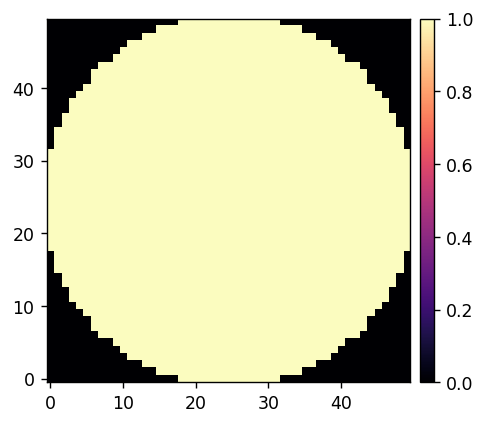

In [2]:
CAMLO_STREAM = ImageStream('camlosim')
ZPO_STREAM = ImageStream('camlo_zpo')
CAMLO_SHUTTER_STREAM = ImageStream('camloshutter')
CAMLO_EXPTIME_STREAM = ImageStream('camloexptime')
CAMLO_GAIN_STREAM = ImageStream('camlogain')
VMAG_STREAM = ImageStream('vmag')

DM_STREAMS = []
for i in range(5):
    DM_STREAMS.append(ImageStream(f'dmdisp{i:02}sim'))

rt_utils.create_shmim('llowfsc_gains', (10, 1))
GAINS_STREAM = ImageStream('llowfsc_gains')
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.05]))

Ncamlo = CAMLO_STREAM.shape[0]
Nact = DM_STREAMS[0].shape[0]

dm_mask = dm.create_mask(Nact=Nact, return_np=1)
utils.imshow(
    [dm_mask]
)

In [3]:
VMAG_STREAM.write(np.array([[0]]))

In [26]:
rt_utils.write(CAMLO_EXPTIME_STREAM, [10e-3])


In [3]:
def take_im_fun(
        CAMLO_STREAM,
        NFRAMES=1,
    ):
    camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0)
    # camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0) if NFRAMES>1 else CAMLO_STREAM.grab_after(1,0)[0]
    return camlo_im

take_im_params = {
    'CAMLO_STREAM':CAMLO_STREAM,
    'NFRAMES':1,
}

def set_dm_fun(
        command,
        DM_STREAM,
    ):

    DM_STREAM.write(ensure_np_array(command))

set_dm_params = {
    'DM_STREAM':ImageStream('dmdisp01sim'),
}

def get_dm_fun(
        DM_STREAM,
    ):

    return DM_STREAM.grab_latest()


get_dm_params = {
    'DM_STREAM':ImageStream('dmdisp01sim'),
}


def get_gains():
    return GAINS_STREAM.grab_latest()[0]

def get_zpo(ZPO_STREAM):
    return ZPO_STREAM.grab_latest()

get_zpo_params = {
    'ZPO_STREAM':ZPO_STREAM,
}


# Obtain a reference dark image for the camera settings that will be used during the duration of LLOWFSC.

INFO:utils:Got semaphore index 1.


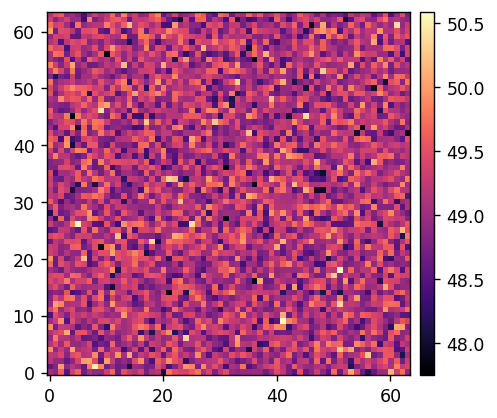

In [4]:

take_im_params.update({
    'NFRAMES':100,
})

CAMLO_SHUTTER_STREAM.write(np.array([[1]]))
time.sleep(0.1)
camlo_dark = take_im_fun(**take_im_params)
CAMLO_SHUTTER_STREAM.write(np.array([[0]]))

utils.imshow([camlo_dark])

# Obtain the reference image.

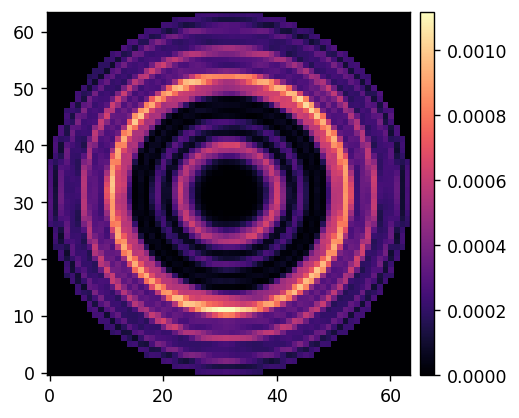

In [5]:
reload(llowfsc)

irad = 3
orad = 32
wfs_mask = utils.create_annular_focal_plane_mask(CAMLO_STREAM.shape[0], 1, irad, orad, edge=None, centering='even', return_np=1)

take_im_params.update({
    'NFRAMES':100,
})

ref_im, flux_norm_coeff = llowfsc.acquire_ref(
    take_im_fun,
    take_im_params,
    wfs_mask,
    camlo_dark=camlo_dark,
    flux_norm=True,
)

utils.imshow(
    [ref_im], 
)


# Calibrate for the set of Zernike modes that we want to control.

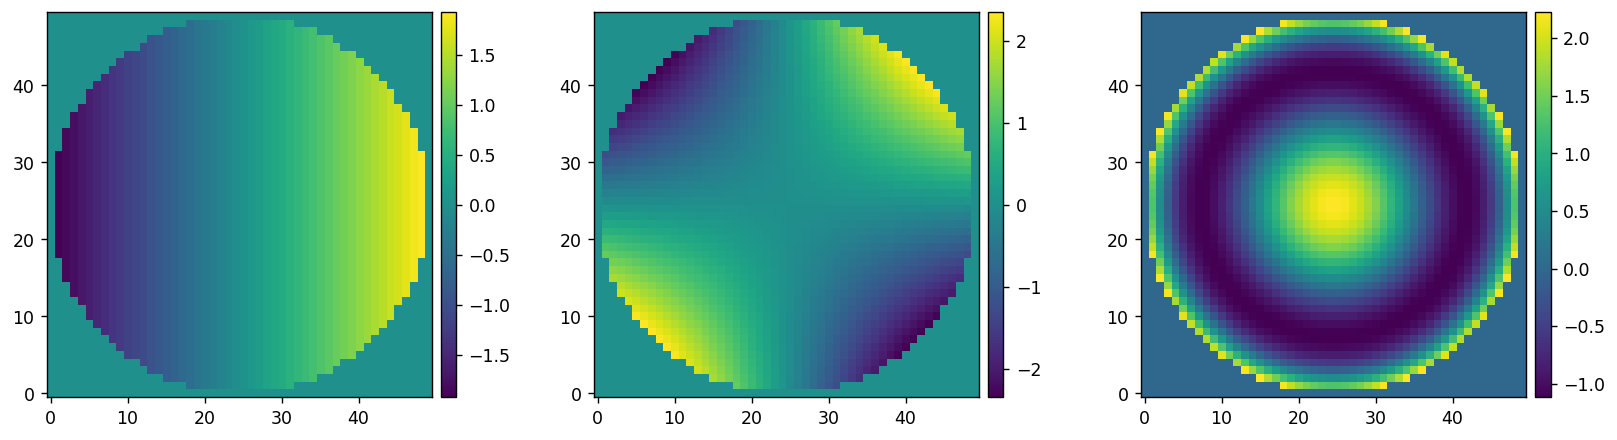

Calibrated mode 1/10 in 0.391s

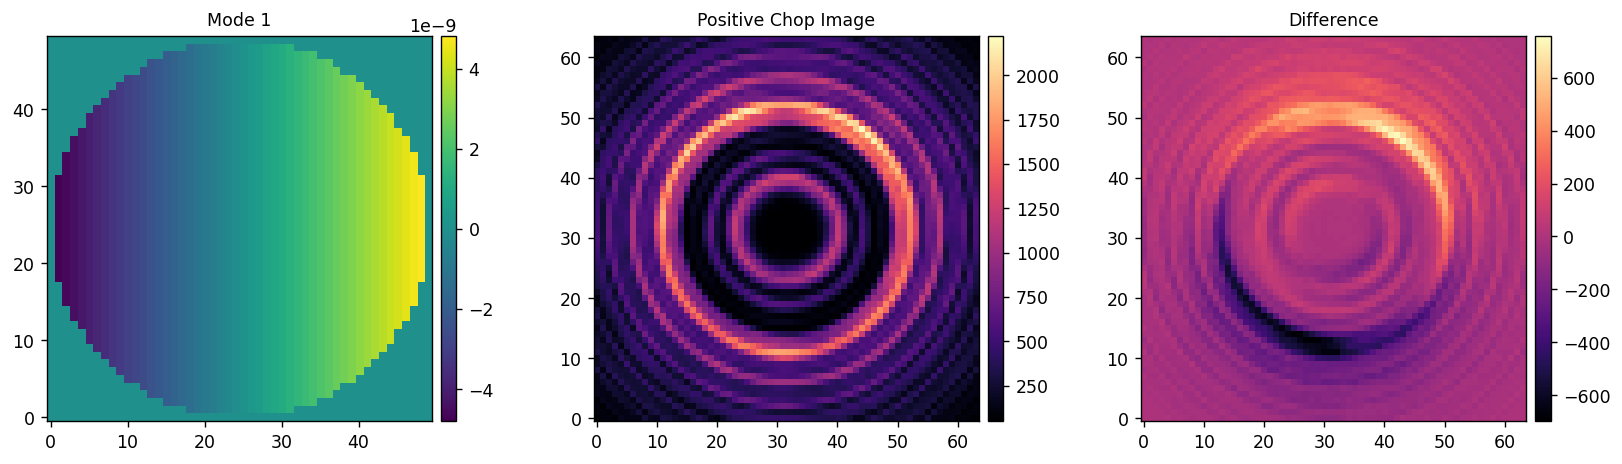

Calibrated mode 2/10 in 1.132s

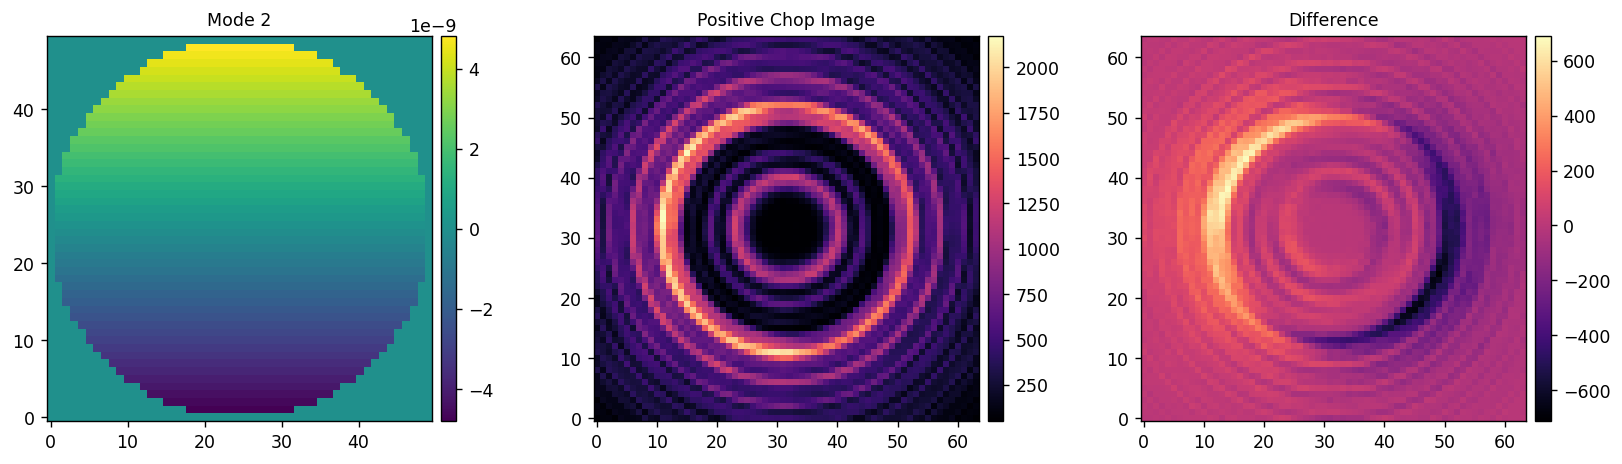

Calibrated mode 3/10 in 1.832s

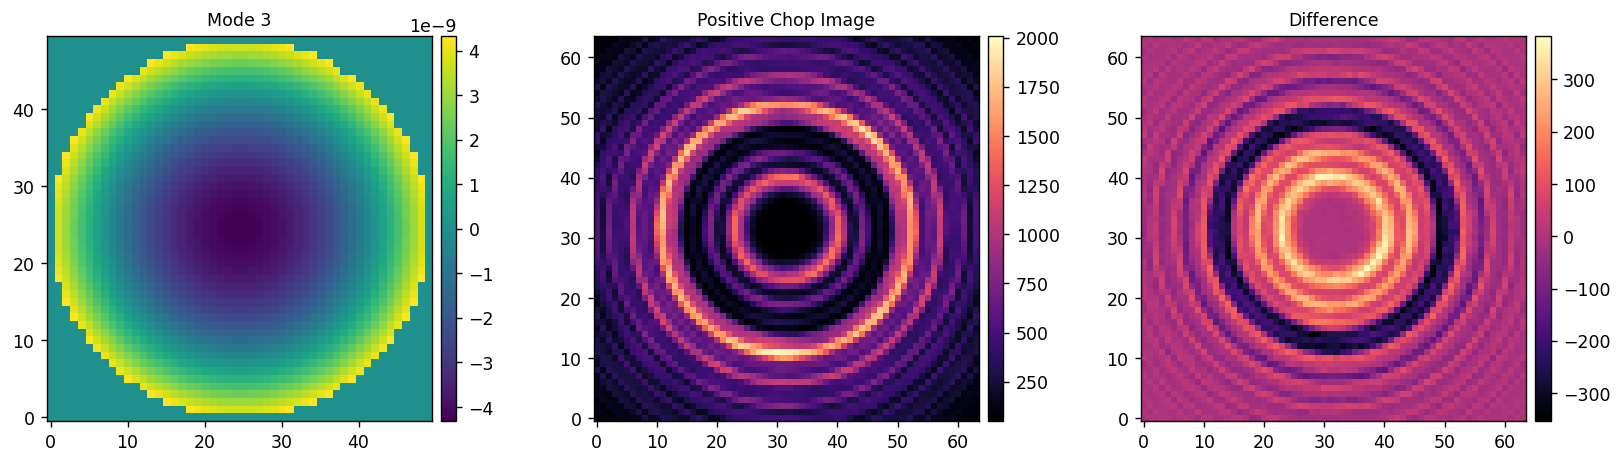

Calibrated mode 4/10 in 2.532s

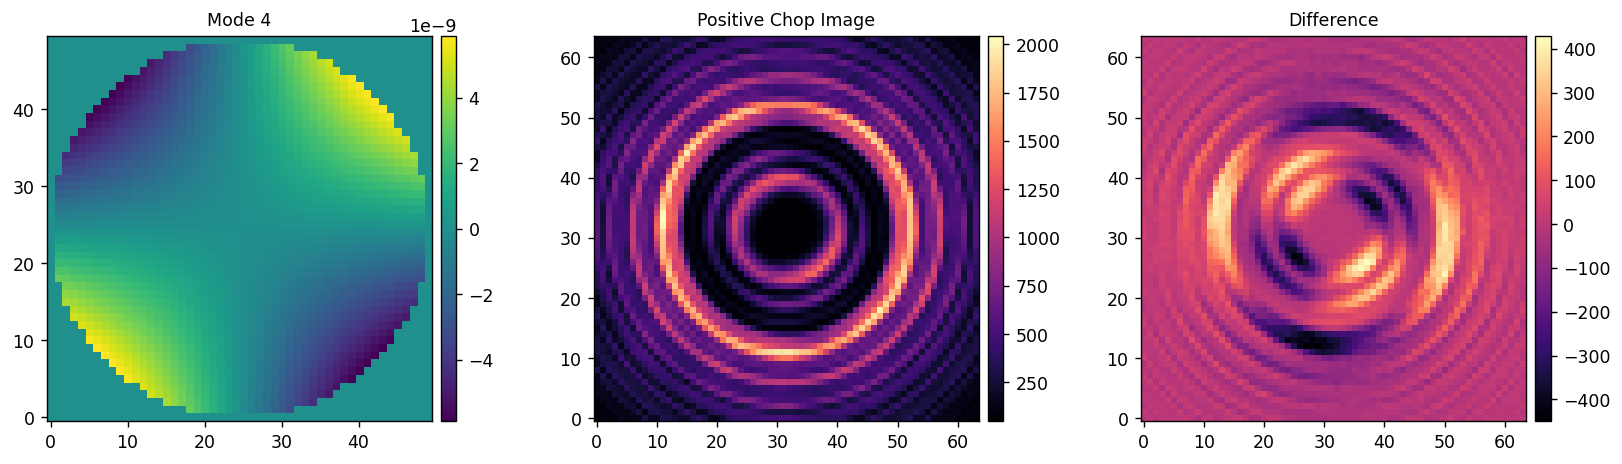

Calibrated mode 5/10 in 3.312s

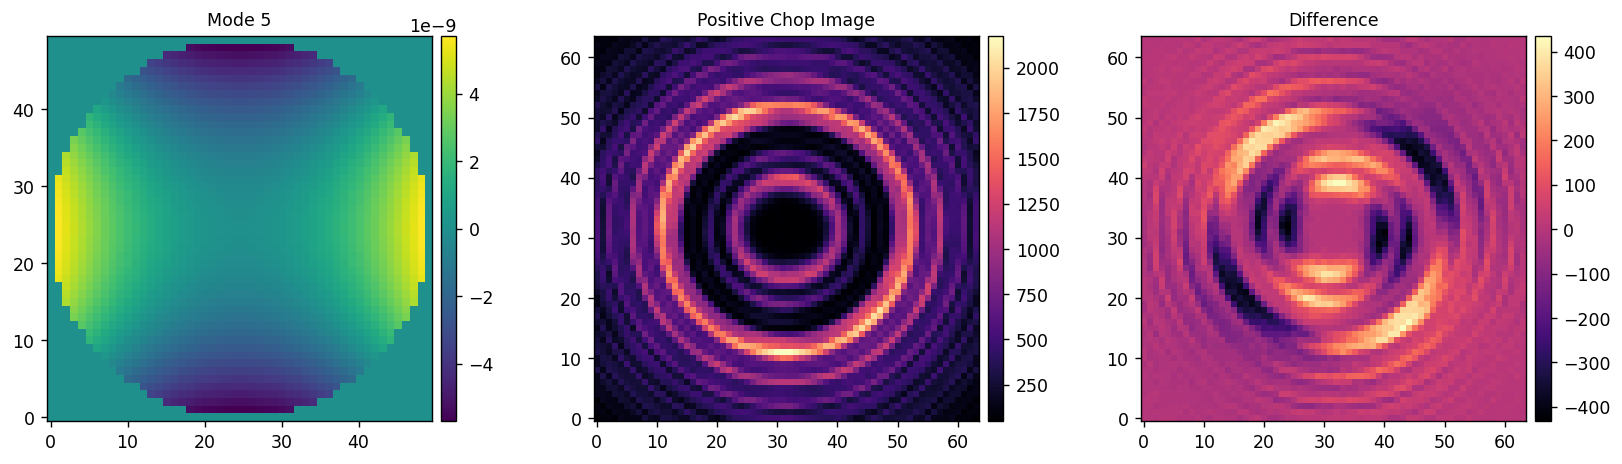

Calibrated mode 6/10 in 4.012s

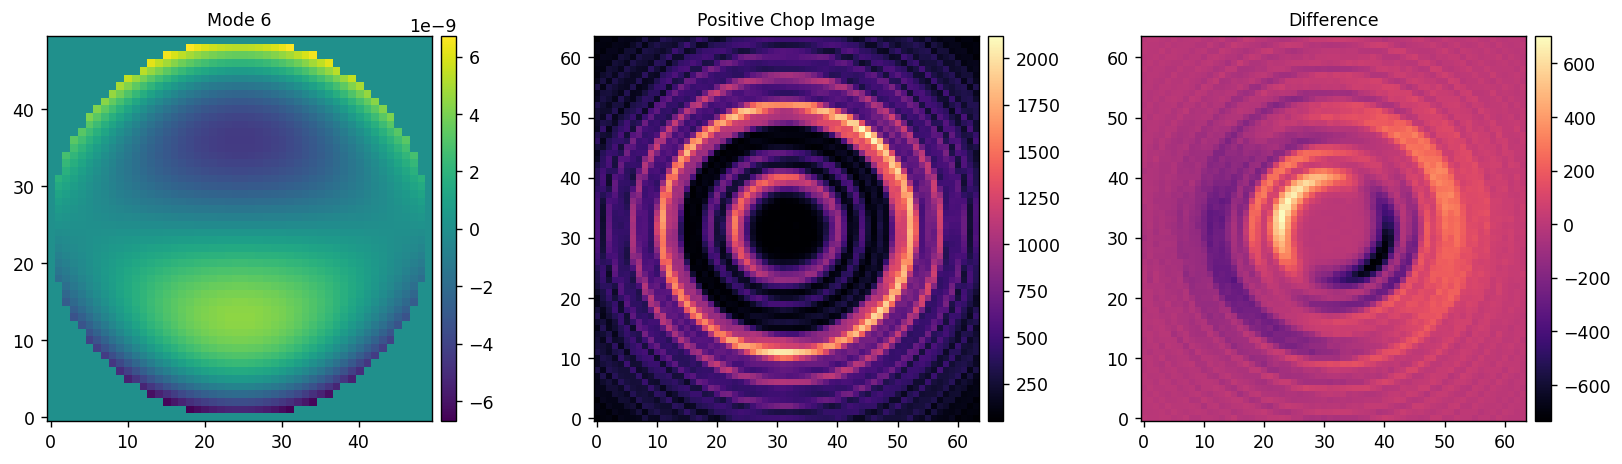

Calibrated mode 7/10 in 4.711s

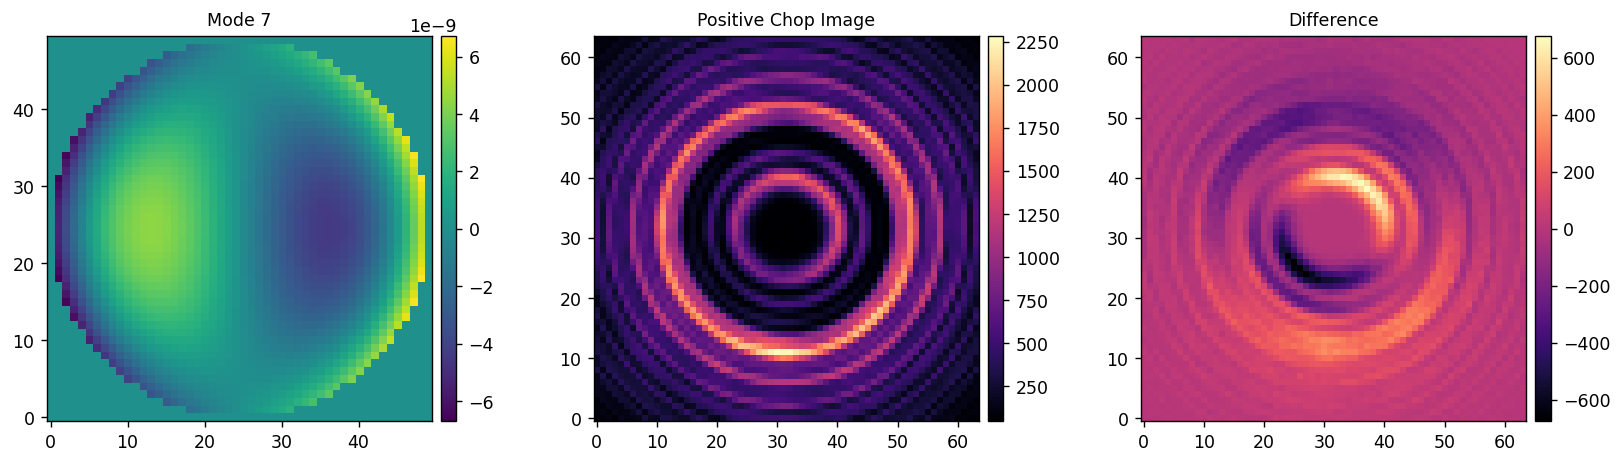

Calibrated mode 8/10 in 5.412s

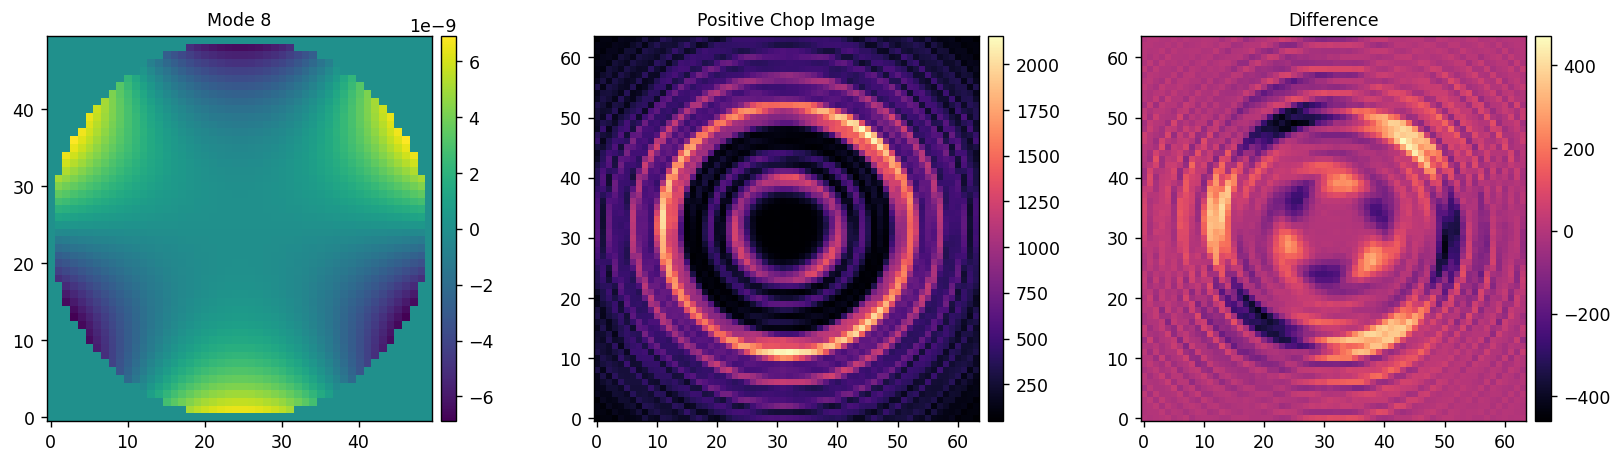

Calibrated mode 9/10 in 6.111s

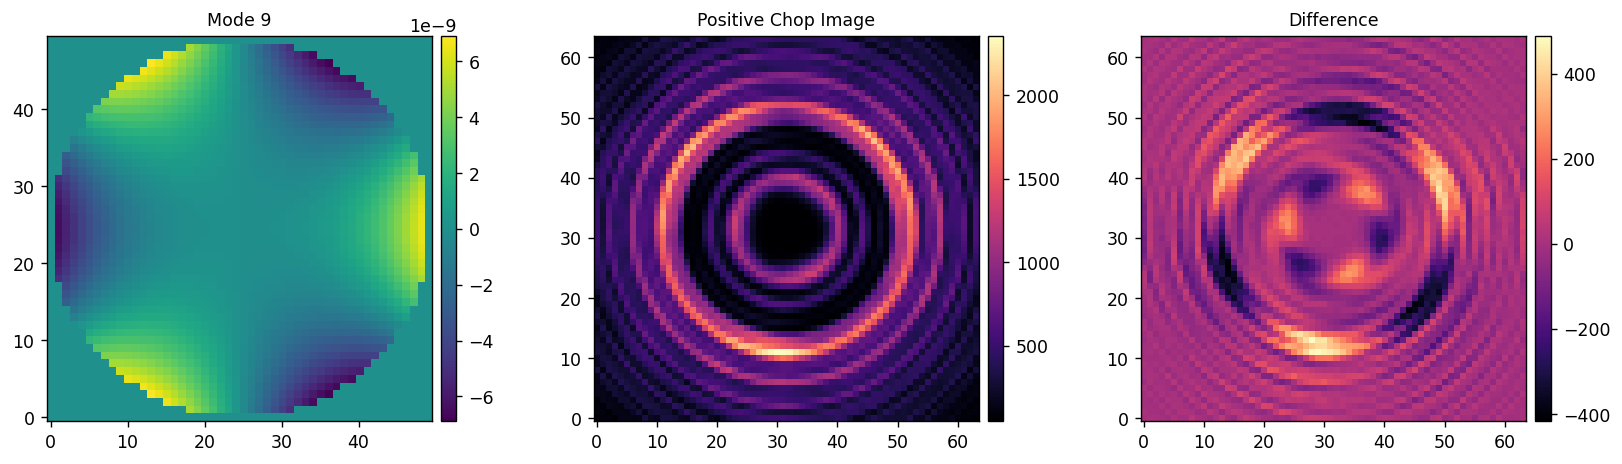

Calibrated mode 10/10 in 6.882s

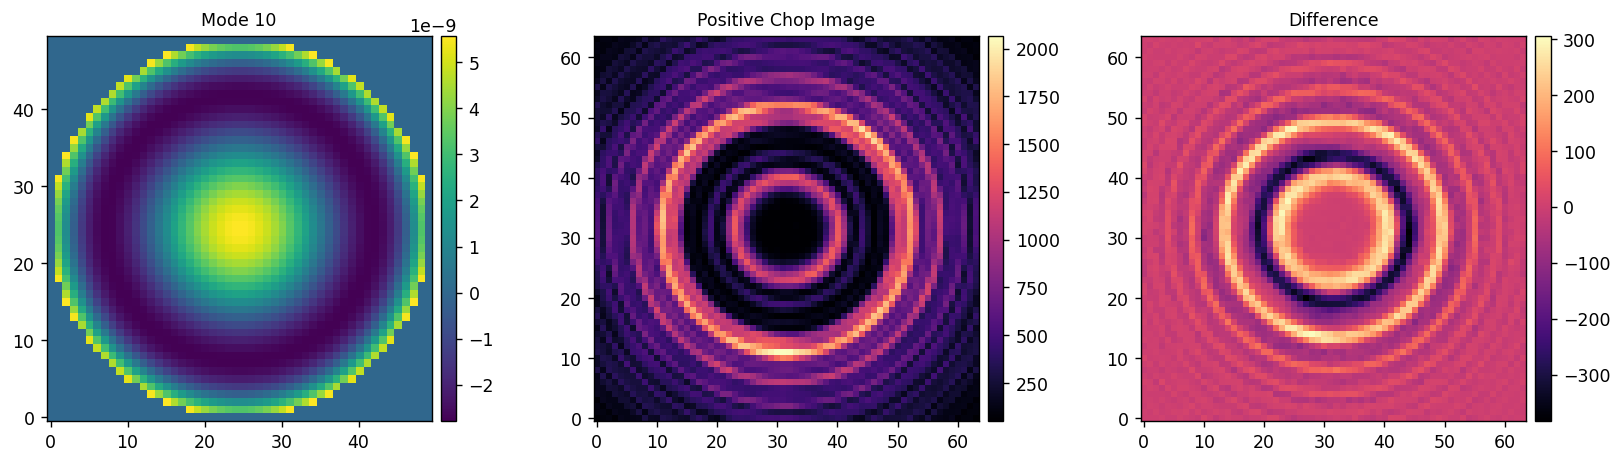

In [6]:
reload(llowfsc)
reload(dm)
reload(utils)

Nmodes = 10

dm_zer_mask = utils.pad_or_crop(dm.create_mask(Nact=Nact-2, return_np=1), DM_STREAMS[0].shape[0])
dm_zernike_modes = dm.create_zernike_modes(dm_zer_mask, nmodes=Nmodes, remove_modes=1, return_np=1)
utils.imshow([dm_zernike_modes[0], dm_zernike_modes[3], dm_zernike_modes[-1]], cmaps=3*['viridis'])

take_im_params.update({
    'NFRAMES':20,
})

zer_rm, zer_response_cube = llowfsc.calibrate_dm_modes(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    dm_zernike_modes, 
    wfs_mask, 
    amp=2.5e-9, 
    flux_norm_coeff=flux_norm_coeff,
    # include_factor_2=True, 
    plot=True,
)


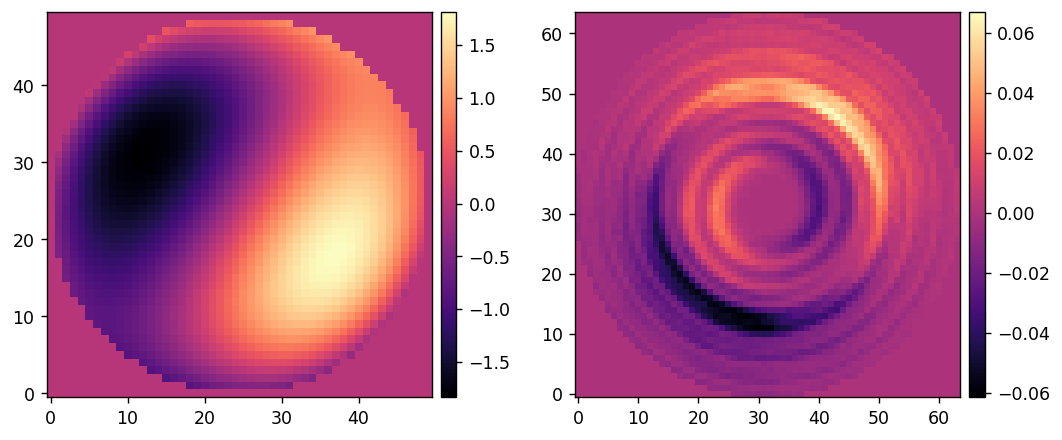

In [7]:
reload(utils)
P, U, s, Vt = utils.tikhonov_inverse(zer_rm, 0, return_all=1, return_np=1)

dm_modes = np.zeros((Nmodes, Nact, Nact))
wfs_modes = np.zeros((Nmodes, Ncamlo, Ncamlo))
for i in range(Nmodes):
    dm_modes[i, dm_mask] = Vt.dot(dm_zernike_modes[:, dm_mask])[i]
    wfs_modes[i, wfs_mask] = U.T[i] 

i = 0
utils.imshow(
    [dm_modes[i], wfs_modes[i]]
)

# Run LLOWFSC process

In [58]:
import multiprocessing

take_im_params.update({
    'NFRAMES':1,
})

def run_llowfsc():
    while True:
        llowfsc.run(
            take_im_fun,
            take_im_params,
            set_dm_fun,
            set_dm_params,
            get_dm_fun,
            get_dm_params,
            get_gains,
            ref_im,
            P,
            dm_zernike_modes,
            wfs_mask,
            dark_im=camlo_dark,
            get_zpo=get_zpo,
            get_zpo_params=get_zpo_params,
        )

llowfsc_proc = multiprocessing.Process(target=run_llowfsc)


In [59]:
llowfsc_proc.start()
print(f'LLOWFSC process ID: {llowfsc_proc.pid}',)

LLOWFSC process ID: 1787306


In [60]:
llowfsc_proc.terminate()

In [89]:
reload(llowfsc)

args = [
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    get_dm_fun,
    get_dm_params,
    get_gains,
    ref_im,
    P,
    dm_zernike_modes,
    wfs_mask,
]

kwargs = {
    'dark_im':camlo_dark,
    'get_zpo':get_zpo,
    'get_zpo_params':get_zpo_params,
}

llowfsc_proc = llowfsc.ContinuousProcess(llowfsc.run, args, kwargs)


In [90]:
llowfsc_proc.start()

UNNAMED process started. PID = 1787779


In [98]:
llowfsc_proc.stop()

UNNAMED process terminated.


In [92]:
rt_utils.write(GAINS_STREAM, np.array(2*[0.5] + 8*[0.01]))

# Run ZPO Process

In [83]:
def compute_zpo(
        DM_STREAMS,
        dm_mask,
        wfs_mask,
        response_matrix,
        dm_modal_matrix,
        ZPO_STREAM,
    ):
    zpo = np.zeros((wfs_mask.shape[0], wfs_mask.shape[1]))
    for i in range(len(DM_STREAMS)):
        zpo[wfs_mask] += response_matrix.dot( dm_modal_matrix.dot(DM_STREAMS[i].grab_latest()[dm_mask]) )

    ZPO_STREAM.write(zpo)

zpo_params = {
    # 'DM_STREAMS':DM_STREAMS[2:],
    'DM_STREAMS':[DM_STREAMS[2]],
    'dm_mask':dm_mask,
    'wfs_mask':wfs_mask,
    'response_matrix':zer_rm, 'dm_modal_matrix':dm_zernike_modes[:, dm_mask]/952 / 2,
    # 'response_matrix':had_rm, 'dm_modal_matrix':dm_had_modes[:, dm_mask]/1024,
    'ZPO_STREAM':ZPO_STREAM,
}


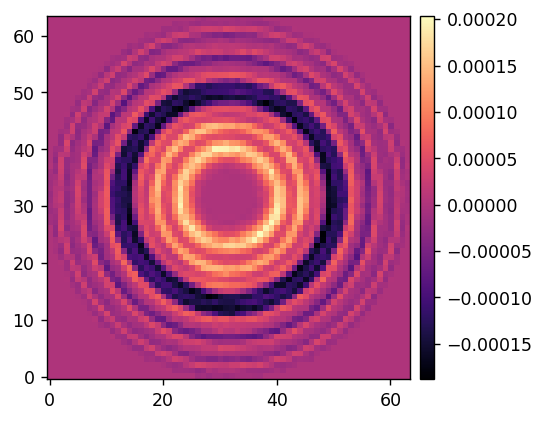

In [84]:
DM_STREAMS[2].write(5e-9 * dm_zernike_modes[2])

compute_zpo(**zpo_params)

zpo = ZPO_STREAM.grab_latest()

utils.imshow(
    [zpo]
)

In [85]:
%%timeit -n 1000
zpo = compute_zpo(**zpo_params)

38.6 μs ± 11.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [86]:
reload(llowfsc)
zpo_freq = 500

zpo_process = llowfsc.TimedThread(
    1/zpo_freq,
    compute_zpo,
    kwargs=zpo_params,
)

In [87]:
zpo_process.start()

In [93]:
zpo_process.stop()

Thread stopped.


In [97]:
DM_STREAMS[2].write(0e-9 * dm_zernike_modes[2])

# Do hadamard calibration if desired

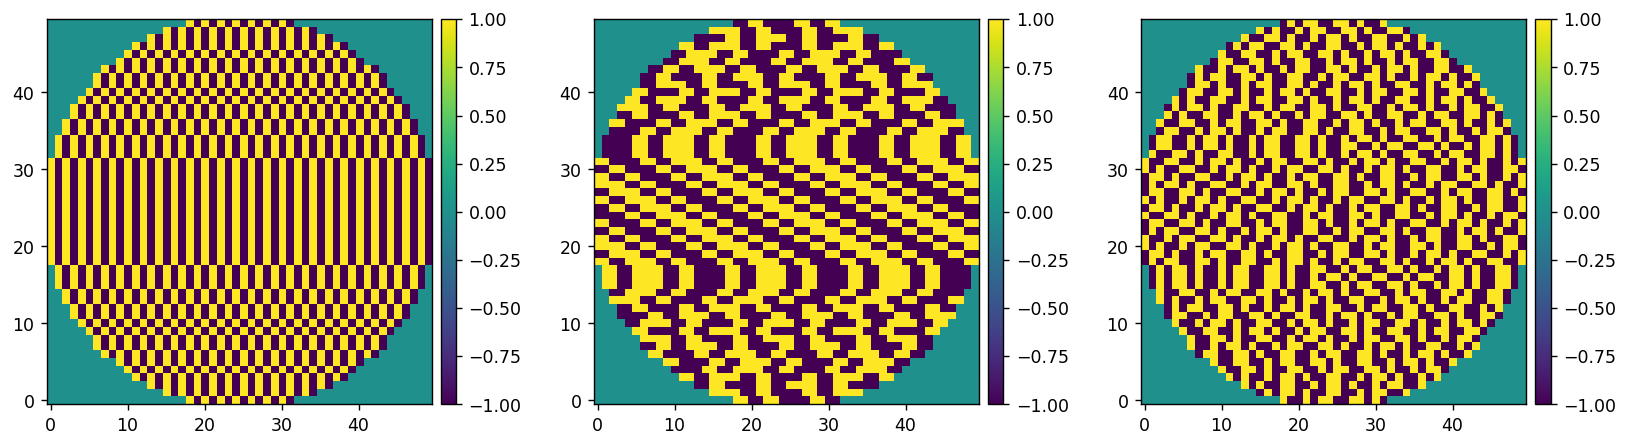

KeyboardInterrupt: 

In [ ]:
reload(llowfsc)
reload(dm)
reload(utils)

dm_had_modes = dm.create_hadamard_modes(dm_mask, return_np=1)
utils.imshow([dm_had_modes[1], dm_had_modes[10], dm_had_modes[-1]], cmaps=3*['viridis'])

# take_im_params.update({
#     'NFRAMES':50,
# })

had_rm, had_response_cube = llowfsc.calibrate_dm_modes(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    dm_had_modes, 
    wfs_mask, 
    amp=2.5e-9, 
    flux_norm_coeff=flux_norm_coeff,
    # include_factor_2=True, 
    # plot=True,
)

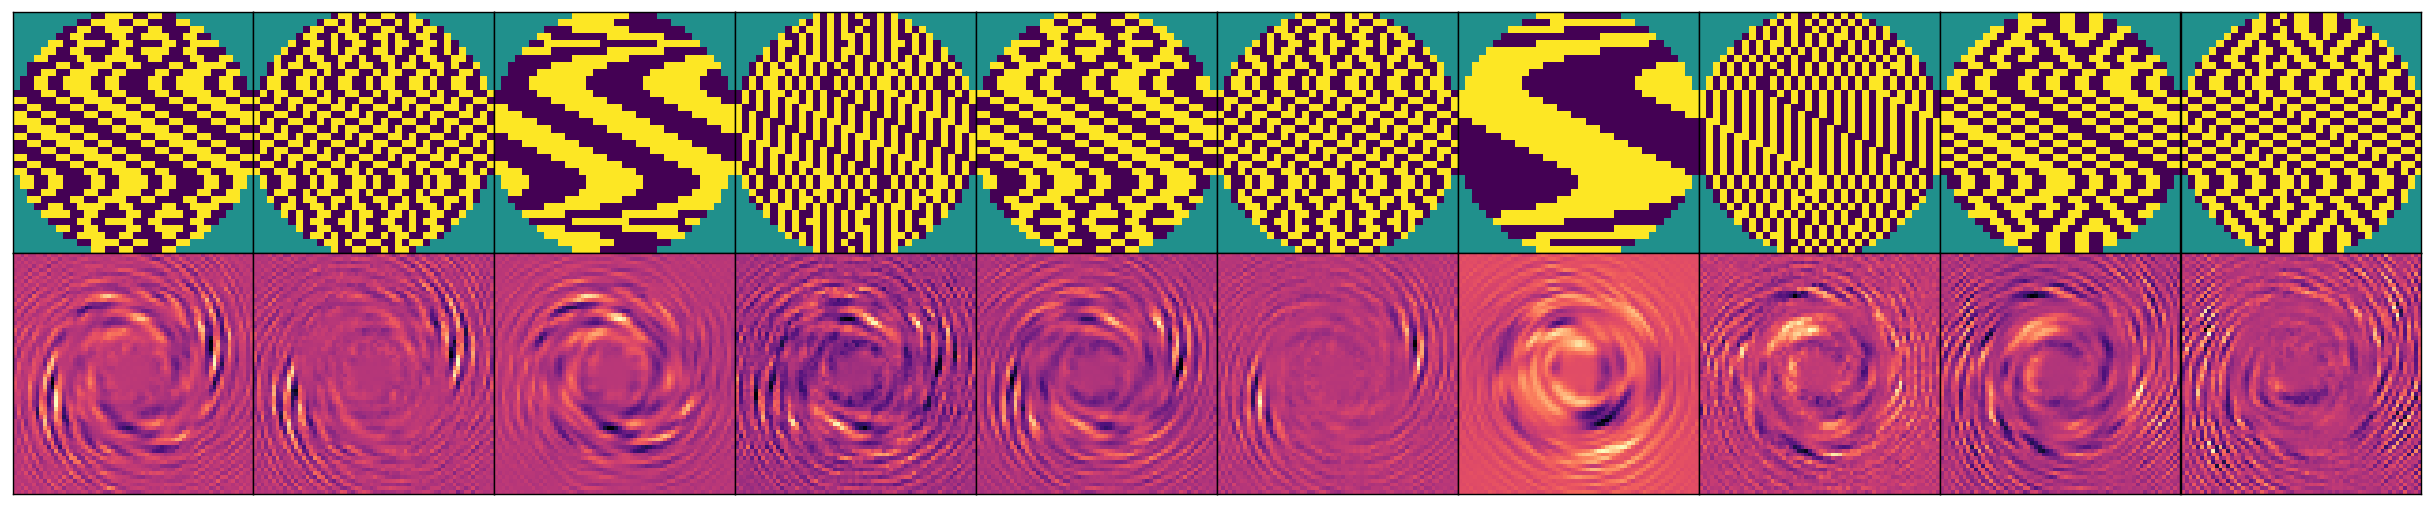

In [ ]:
i = 10
llowfsc.plot_responses(
    dm_had_modes[i:i+10],
    had_response_cube[i:i+10],
)